In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor


In [ ]:
crime_df = pd.read_csv("NCRB_2002_Table_5.3.csv")
patrol_df = pd.read_csv("simulated_patrol_logs.csv")
sos_df = pd.read_csv("simulated_sos_alerts.csv")


In [ ]:
crime_df.columns = (
    crime_df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", " ")
    .str.replace("  ", " ")
)


In [ ]:
crime_keywords = {
    "rape": 5,
    "assault": 4,
    "dowry": 4,
    "kidnapping": 3,
    "cruelty": 3,
    "insult": 2
}

crime_columns = [
    col for col in crime_df.columns
    if any(key in col for key in crime_keywords.keys())
]
print(crime_columns)
print(crime_keywords)

['no. of cases reported (incest rape)', 'no. of victims (incest rape ) - upto 10 years', 'no. of victims (incest rape ) - 10 - 14 years', 'no. of victims (incest rape ) - 14 - 18 years', 'no. of victims (incest rape ) - 18 - 30 years', 'no. of victims (incest rape ) - 30 - 50 years', 'no. of victims (incest rape ) - above 50 years', 'no. of victims (incest rape ) - total victims', 'no. of cases reported (other rape )', 'no. of victims (other rape ) - upto 10 years', 'no. of victims (other rape ) - 10 - 14 years', 'no. of victims (other rape ) - 14 - 18 years', 'no. of victims (other rape ) - 18 - 30 years', 'no. of victims (other rape ) - 30 - 50 years', 'no. of victims (other rape ) - above 50 years', 'no. of victims (other rape ) - total victims', 'no. of cases reported rape cases (total)', 'no. of victims rape cases (total) - upto 10 years', 'no. of victims rape cases (total) - 10 - 14 years', 'no. of victims rape cases (total) - 14 - 18 years', 'no. of victims rape cases (total) - 

In [ ]:
crime_df["crime_count"] = crime_df[crime_columns].sum(axis=1)


In [ ]:
crime_weights = {
    "Rape": 5,
    "Assault on Women": 4,
    "Kidnapping & Abduction": 3,
    "Cruelty by Husband": 3,
    "Insult to Modesty": 2,
    "Dowry Deaths": 4
}
print(crime_weights)

{'Rape': 5, 'Assault on Women': 4, 'Kidnapping & Abduction': 3, 'Cruelty by Husband': 3, 'Insult to Modesty': 2, 'Dowry Deaths': 4}


In [ ]:
crime_df["Severity_Score"] = 0

for crime, weight in crime_weights.items():
    if crime in crime_df.columns:
        crime_df["Severity_Score"] += crime_df[crime] * weight


In [ ]:
crime_df["severity_weight"] = 0

for col in crime_columns:
    for key, weight in crime_keywords.items():
        if key in col:
            crime_df["severity_weight"] += crime_df[col] * weight


In [ ]:
scaler = MinMaxScaler()

crime_df["crime_n"] = scaler.fit_transform(crime_df[["crime_count"]])
crime_df["severity_n"] = scaler.fit_transform(crime_df[["severity_weight"]])

crime_df["wsri"] = (
    0.6 * crime_df["crime_n"] +
    0.4 * crime_df["severity_n"]
)

crime_df["risk_level"] = pd.cut(
    crime_df["wsri"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)


In [ ]:
crime_columns = [
    "Rape",
    "Kidnapping & Abduction",
    "Dowry Deaths",
    "Assault on Women",
    "Cruelty by Husband",
    "Insult to Modesty"
]
print(crime_columns)

['Rape', 'Kidnapping & Abduction', 'Dowry Deaths', 'Assault on Women', 'Cruelty by Husband', 'Insult to Modesty']


In [ ]:
crime_weights = {
    "Rape": 5,
    "Assault on Women": 4,
    "Dowry Deaths": 4,
    "Kidnapping & Abduction": 3,
    "Cruelty by Husband": 3,
    "Insult to Modesty": 2
}

crime_df["Severity_Weight"] = 0
for crime, weight in crime_weights.items():
    if crime in crime_df.columns:
        crime_df["Severity_Weight"] += crime_df[crime] * weight


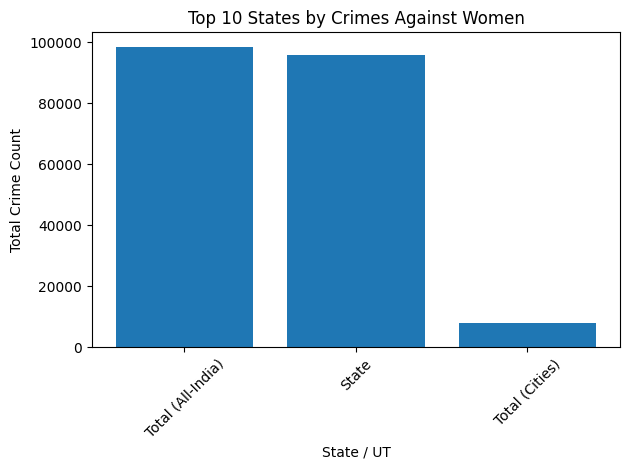

In [ ]:
state_col = crime_df.columns[0]  # State/UT column

top_crime = crime_df.sort_values(
    "crime_count", ascending=False
).head(10)

plt.figure()
plt.bar(top_crime[state_col], top_crime["crime_count"])
plt.xticks(rotation=45)
plt.xlabel("State / UT")
plt.ylabel("Total Crime Count")
plt.title("Top 10 States by Crimes Against Women")
plt.tight_layout()
plt.show()


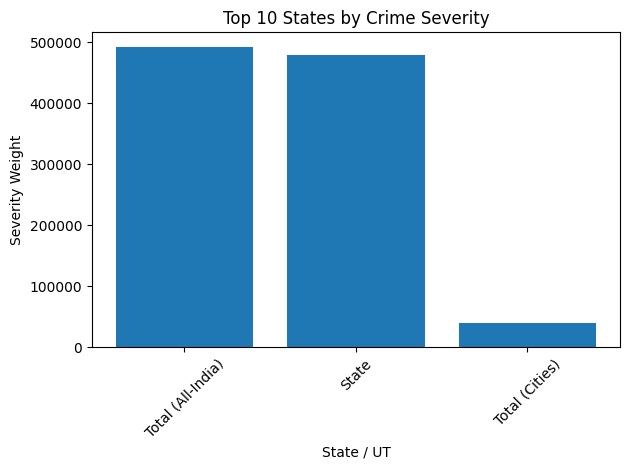

In [ ]:
top_severity = crime_df.sort_values(
    "severity_weight", ascending=False
).head(10)

plt.figure()
plt.bar(top_severity[state_col], top_severity["severity_weight"])
plt.xticks(rotation=45)
plt.xlabel("State / UT")
plt.ylabel("Severity Weight")
plt.title("Top 10 States by Crime Severity")
plt.tight_layout()
plt.show()


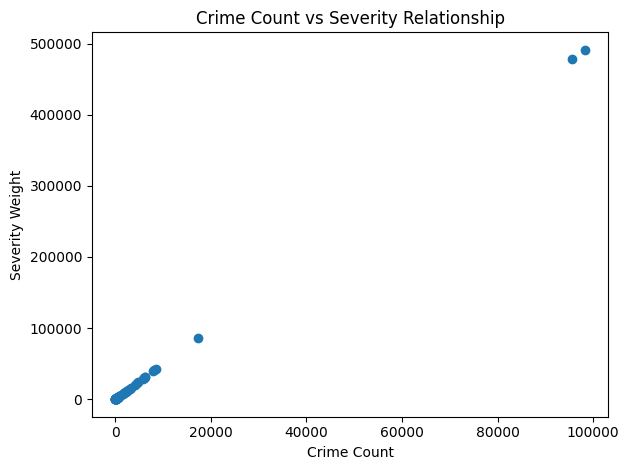

In [ ]:
plt.figure()
plt.scatter(
    crime_df["crime_count"],
    crime_df["severity_weight"]
)
plt.xlabel("Crime Count")
plt.ylabel("Severity Weight")
plt.title("Crime Count vs Severity Relationship")
plt.tight_layout()
plt.show()


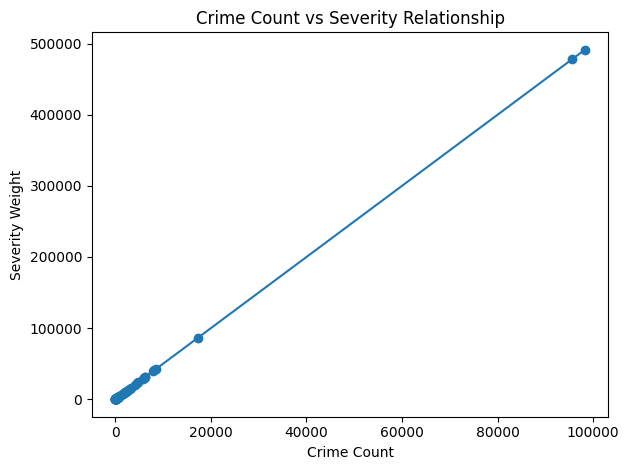

In [ ]:
import matplotlib.pyplot as plt

sorted_df = crime_df.sort_values("crime_count")

plt.figure()
plt.plot(
    sorted_df["crime_count"],
    sorted_df["severity_weight"],
    marker="o"
)

plt.xlabel("Crime Count")
plt.ylabel("Severity Weight")
plt.title("Crime Count vs Severity Relationship")
plt.tight_layout()
plt.show()


In [ ]:
sos_features = sos_df.select_dtypes(include=np.number)

iso = IsolationForest(contamination=0.05, random_state=42)
sos_df["anomaly"] = iso.fit_predict(sos_features)

sos_df["anomaly"] = sos_df["anomaly"].map({-1: "Anomaly", 1: "Normal"})
sos_anomalies = sos_df[sos_df["anomaly"] == "Anomaly"]
print("Sample SOS Anomalies:")
print(sos_anomalies.head())



Sample SOS Anomalies:
    Alert_ID User_ID                 Time     City  Latitude  Longitude  \
6      A0007   U1711  2023-07-01 18:43:02  Chennai   13.0851    80.2516   
8      A0009   U1750  2023-07-01 18:55:09   Mumbai   19.0659    72.8808   
40     A0041   U1828  2023-07-01 19:30:49  Kolkata   22.5704    88.3675   
64     A0065   U3532  2023-07-01 21:45:10   Mumbai   19.0770    72.8727   
110    A0111   U2129  2023-07-01 22:27:42  Kolkata   22.5957    88.3452   

       Zone  Delay_Minutes    Alert_Type  anomaly  
6    Yellow             30    Auto Alert  Anomaly  
8    Yellow             30  Panic Button  Anomaly  
40    Green             30  Panic Button  Anomaly  
64    Green             30  Panic Button  Anomaly  
110  Yellow              0    Auto Alert  Anomaly  


In [ ]:
patrol_features = patrol_df.select_dtypes(include=np.number)

lof = LocalOutlierFactor(contamination=0.05)
patrol_df["anomaly"] = lof.fit_predict(patrol_features)

patrol_df["anomaly"] = patrol_df["anomaly"].map({-1: "Anomaly", 1: "Normal"})
patrol_anomalies = patrol_df[patrol_df["anomaly"] == "Anomaly"]
print("Sample Patrol Anomalies:")
print(patrol_anomalies.head())


Sample Patrol Anomalies:
Empty DataFrame
Columns: [Patrol_ID, City, Start_Time, End_Time, Route_Covered, Alerts_Responded, anomaly]
Index: []


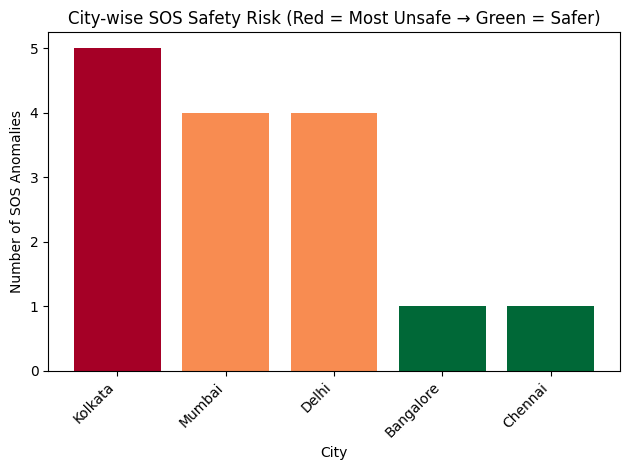

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

CITY_COL = "City"

city_anomaly_counts = (
    sos_df[sos_df["anomaly"] == "Anomaly"]
    .groupby(CITY_COL)
    .size()
    .sort_values(ascending=False)
)

scaler = MinMaxScaler()
normalized_risk = scaler.fit_transform(
    city_anomaly_counts.values.reshape(-1, 1)
).flatten()

colors = plt.cm.RdYlGn_r(normalized_risk)

plt.figure()
plt.bar(
    city_anomaly_counts.index.astype(str),
    city_anomaly_counts.values,
    color=colors
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("City")
plt.ylabel("Number of SOS Anomalies")
plt.title("City-wise SOS Safety Risk (Red = Most Unsafe → Green = Safer)")
plt.tight_layout()
plt.show()


In [ ]:
# Install dependencies if not installed
# pip install networkx matplotlib deap numpy

import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from deap import base, creator, tools, algorithms

# ---------------------------
# 1. CREATE GRAPH (Example)
# ---------------------------
G = nx.Graph()
edges = [
    ("A", "B", 2), ("A", "C", 5),
    ("B", "C", 1), ("B", "D", 4),
    ("C", "D", 2), ("C", "E", 3),
    ("D", "E", 1)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)  # weight = risk score

# ---------------------------
# 2. DIJKSTRA ALGORITHM
# ---------------------------
start, end = "A", "E"
dijkstra_path = nx.dijkstra_path(G, source=start, target=end, weight="weight")
dijkstra_cost = nx.dijkstra_path_length(G, source=start, target=end, weight="weight")

print("Dijkstra Path:", dijkstra_path)
print("Dijkstra Cost (Risk):", dijkstra_cost)

# ---------------------------
# 3. A* ALGORITHM
# ---------------------------
# For heuristic, we’ll use simple straight-line distances (dummy heuristic)
# Here, we'll just use 0 heuristic for demonstration (becomes Dijkstra)
def heuristic(u, v):
    return 0

a_star_path = nx.astar_path(G, start, end, heuristic=heuristic, weight="weight")
a_star_cost = nx.astar_path_length(G, start, end, heuristic=heuristic, weight="weight")

print("A* Path:", a_star_path)
print("A* Cost (Risk):", a_star_cost)

# ---------------------------
# 4. GENETIC ALGORITHM
# ---------------------------
# Objective: Find path covering all nodes with minimal total risk
nodes = list(G.nodes)

# Prevent RuntimeWarning if the cell is executed multiple times
if "FitnessMin" in creator.__dict__:
    del creator.__dict__["FitnessMin"]
if "Individual" in creator.__dict__:
    del creator.__dict__["Individual"]

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # minimize risk
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("indices", random.sample, nodes, len(nodes))
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def path_risk(individual):
    risk = 0
    for i in range(len(individual)-1):
        u, v = individual[i], individual[i+1]
        if G.has_edge(u, v):
            risk += G[u][v]["weight"]
        else:
            risk += 10  # penalty for invalid path
    return (risk,)

toolbox.register("evaluate", path_risk)
toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=50)
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=50, verbose=False)

best_individual = tools.selBest(population, k=1)[0]
print("GA Best Path:", best_individual)
print("GA Risk Score:", path_risk(best_individual)[0])

# ---------------------------
# 5. VISUALIZE GRAPH
# ---------------------------
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1500, font_size=14)
nx.draw_networkx_edges(G, pos, edgelist=[(dijkstra_path[i], dijkstra_path[i+1]) for i in range(len(dijkstra_path)-1)], edge_color="green", width=2)
plt.title("Green Edge = Dijkstra Shortest Path")
plt.show()


Dijkstra Path: ['A', 'B', 'C', 'E']
Dijkstra Cost (Risk): 6
A* Path: ['A', 'B', 'C', 'E']
A* Cost (Risk): 6


TypeError: list indices must be integers or slices, not str

In [ ]:
!pip install deap


In [ ]:
# Map nodes to integers
node_list = list(G.nodes)
node_to_int = {node: i for i, node in enumerate(node_list)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Convert edges to use integers
G_int = nx.Graph()
for u, v, w in edges:
    G_int.add_edge(node_to_int[u], node_to_int[v], weight=w)

# GA individuals are now lists of integers
nodes_int = list(G_int.nodes)


Dijkstra Path: ['A', 'B', 'C', 'E']
Dijkstra Cost (Risk): 6
A* Path: ['A', 'B', 'C', 'E']
A* Cost (Risk): 6
GA Best Path: ['E', 'D', 'C', 'B', 'A']
GA Risk Score: 6


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


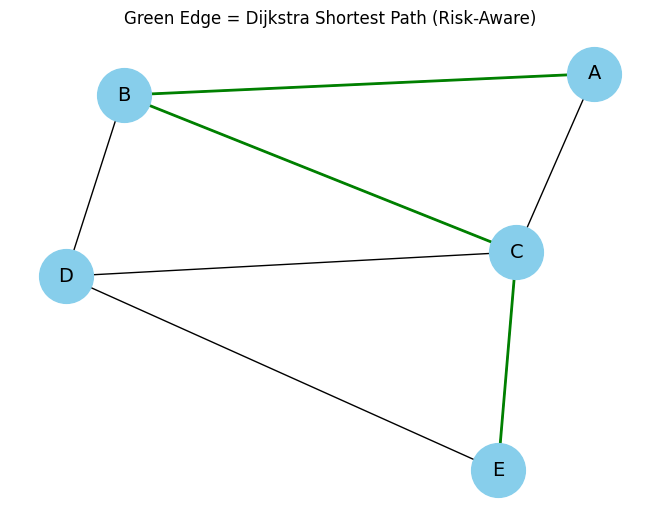

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install networkx matplotlib deap numpy

import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from deap import base, creator, tools, algorithms

# ---------------------------
# 1. CREATE GRAPH
# ---------------------------
G = nx.Graph()
edges = [
    ("A", "B", 2), ("A", "C", 5),
    ("B", "C", 1), ("B", "D", 4),
    ("C", "D", 2), ("C", "E", 3),
    ("D", "E", 1)
]

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

start, end = "A", "E"

# ---------------------------
# 2. DIJKSTRA
# ---------------------------
dijkstra_path = nx.dijkstra_path(G, source=start, target=end, weight="weight")
dijkstra_cost = nx.dijkstra_path_length(G, source=start, target=end, weight="weight")

print("Dijkstra Path:", dijkstra_path)
print("Dijkstra Cost (Risk):", dijkstra_cost)

# ---------------------------
# 3. A* (Heuristic = 0, same as Dijkstra for demo)
# ---------------------------
def heuristic(u, v):
    return 0  # replace with better heuristic if available

a_star_path = nx.astar_path(G, start, end, heuristic=heuristic, weight="weight")
a_star_cost = nx.astar_path_length(G, start, end, heuristic=heuristic, weight="weight")

print("A* Path:", a_star_path)
print("A* Cost (Risk):", a_star_cost)

# ---------------------------
# 4. GENETIC ALGORITHM
# ---------------------------
# Map nodes to integers for DEAP
node_list = list(G.nodes)
node_to_int = {node: i for i, node in enumerate(node_list)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Convert edges to integer nodes
G_int = nx.Graph()
for u, v, w in edges:
    G_int.add_edge(node_to_int[u], node_to_int[v], weight=w)

nodes_int = list(G_int.nodes)

# DEAP setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # minimize risk
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("indices", random.sample, nodes_int, len(nodes_int))
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def path_risk(individual):
    risk = 0
    for i in range(len(individual)-1):
        u, v = individual[i], individual[i+1]
        if G_int.has_edge(u, v):
            risk += G_int[u][v]["weight"]
        else:
            risk += 10  # penalty for invalid path
    return (risk,)

toolbox.register("evaluate", path_risk)
toolbox.register("mate", tools.cxPartialyMatched)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Run GA
population = toolbox.population(n=50)
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=50, verbose=False)

best_individual = tools.selBest(population, k=1)[0]
best_path_nodes = [int_to_node[i] for i in best_individual]
best_risk = path_risk(best_individual)[0]

print("GA Best Path:", best_path_nodes)
print("GA Risk Score:", best_risk)

# ---------------------------
# 5. VISUALIZE GRAPH
# ---------------------------
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1500, font_size=14)
# Highlight Dijkstra path
nx.draw_networkx_edges(G, pos, edgelist=[(dijkstra_path[i], dijkstra_path[i+1]) for i in range(len(dijkstra_path)-1)], edge_color="green", width=2)
plt.title("Green Edge = Dijkstra Shortest Path (Risk-Aware)")
plt.show()


Dijkstra Paths to High-Risk Zones:
C: Path=['A', 'B', 'C'], Cost=3
E: Path=['A', 'B', 'C', 'E'], Cost=6

A* Paths to High-Risk Zones:
C: Path=['A', 'B', 'C'], Cost=3
E: Path=['A', 'B', 'C', 'E'], Cost=6

GA Best Route: ['E', 'C', 'E']
GA Risk Score: 6


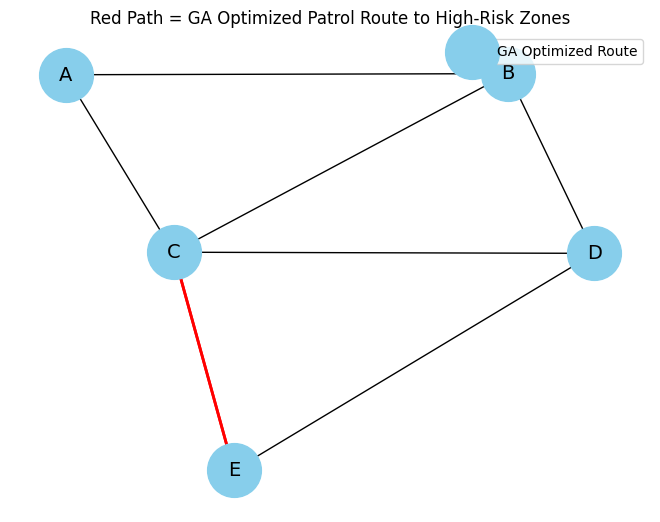

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from deap import base, creator, tools, algorithms

# ------------------ GRAPH AND RISK SETUP ------------------
G = nx.Graph()
edges = [
    ("A", "B", 2), ("A", "C", 5),
    ("B", "C", 1), ("B", "D", 4),
    ("C", "D", 2), ("C", "E", 3),
    ("D", "E", 1)
]

risk_level = {
    "A": 2,  # Low risk
    "B": 5,  # Medium
    "C": 9,  # High
    "D": 7,  # Medium
    "E": 10  # High
}

for u, v, w in edges:
    G.add_edge(u, v, weight=w)

start = "A"

high_risk_nodes = [node for node, risk in risk_level.items() if risk >= 8]

# Map nodes to integers for DEAP
node_list = list(G.nodes)
node_to_int = {node: i for i, node in enumerate(node_list)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Convert G to G_int for GA operations
G_int = nx.Graph()
for u, v, w in edges:
    G_int.add_edge(node_to_int[u], node_to_int[v], weight=w)

start_int = node_to_int[start]
targets_int = [node_to_int[node] for node in high_risk_nodes]

# ------------------ DIJKSTRA TO HIGHEST RISK ------------------
def dijkstra_to_high_risk(graph, start, targets):
    paths = {}
    for t in targets:
        path = nx.dijkstra_path(graph, source=start, target=t, weight="weight")
        cost = nx.dijkstra_path_length(graph, source=start, target=t, weight="weight")
        paths[t] = (path, cost)
    return paths

dijkstra_paths = dijkstra_to_high_risk(G, start, high_risk_nodes)
print("Dijkstra Paths to High-Risk Zones:")
for t, (p, c) in dijkstra_paths.items():
    print(f"{t}: Path={p}, Cost={c}")

# ------------------ A* TO HIGHEST RISK ------------------
def heuristic(u, v):
    return 0

def a_star_to_high_risk(graph, start, targets):
    paths = {}
    for t in targets:
        path = nx.astar_path(graph, start, t, heuristic=heuristic, weight="weight")
        cost = nx.astar_path_length(graph, start, t, heuristic=heuristic, weight="weight")
        paths[t] = (path, cost)
    return paths

a_star_paths = a_star_to_high_risk(G, start, high_risk_nodes)
print("\nA* Paths to High-Risk Zones:")
for t, (p, c) in a_star_paths.items():
    print(f"{t}: Path={p}, Cost={c}")

# ------------------ GENETIC ALGORITHM FOR MULTI-HIGH-RISK ROUTE ------------------

# Prevent RuntimeWarning if the cell is executed multiple times
if "FitnessMin" in creator.__dict__:
    del creator.__dict__["FitnessMin"]
if "Individual" in creator.__dict__:
    del creator.__dict__["Individual"]

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # minimize risk
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def create_individual():
    nodes_to_visit = targets_int[:] # copy the list
    random.shuffle(nodes_to_visit)
    return [start_int] + nodes_to_visit

toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def route_risk(individual_int):
    risk = 0
    # Map integer indices back to node names for graph lookup
    for i in range(len(individual_int)-1):
        u, v = individual_int[i], individual_int[i+1]
        if G_int.has_edge(u, v):
            risk += G_int[u][v]["weight"]
        else:
            risk += 10 # penalty for invalid path
    return (risk,)

toolbox.register("evaluate", route_risk)

# Custom simple crossover: swap two high-risk nodes (excluding start)
def simple_crossover(ind1, ind2):
    # Ensure we don't modify the start node, only the targets
    a, b = 1, len(ind1) # Indices for target nodes
    if b - a < 2: # Need at least two target nodes to swap
        return ind1, ind2

    # Select two distinct indices for swapping
    idx1, idx2 = random.sample(range(a, b), 2)

    # Perform the swap
    ind1[idx1], ind2[idx2] = ind2[idx2], ind1[idx1]

    return ind1, ind2

toolbox.register("mate", simple_crossover)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=50)
algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=50, verbose=False)

best_individual_int = tools.selBest(population, k=1)[0]
best_route = [int_to_node[i] for i in best_individual_int]

print("\nGA Best Route:", best_route)
print("GA Risk Score:", route_risk(best_individual_int)[0])

# ------------------ VISUALIZATION ------------------
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=1500, font_size=14)

# Draw GA optimized route
ga_edges = [(best_route[i], best_route[i+1]) for i in range(len(best_route)-1)]
nx.draw_networkx_edges(G, pos, edgelist=ga_edges, edge_color="red", width=2, label="GA Optimized Route")

plt.title("Red Path = GA Optimized Patrol Route to High-Risk Zones")
plt.legend(['GA Optimized Route'])
plt.show()